# Preparação do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [4]:
planilha_2016 = 'Felicidade.xlsx'
df = pd.read_excel(planilha_2016, sheet_name=1)

In [5]:
df.head()

,Fonte dos dados: kaggle.com,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Felicidade dos países do mundo no ano de 2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Download em: 19/07/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pais,regiao,felicidade,pib_per_capita,suporte_social,anos_vida_saudavel,liberdade_de_escolha,generosidade,percepcoes_corrupcao,ano,Error_1,Error_2,Error_3


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Fonte dos dados: kaggle.com  160 non-null    str   
 1   Unnamed: 1                   158 non-null    str   
 2   Unnamed: 2                   158 non-null    object
 3   Unnamed: 3                   158 non-null    object
 4   Unnamed: 4                   158 non-null    object
 5   Unnamed: 5                   158 non-null    object
 6   Unnamed: 6                   158 non-null    object
 7   Unnamed: 7                   158 non-null    object
 8   Unnamed: 8                   158 non-null    object
 9   Unnamed: 9                   158 non-null    object
 10  Unnamed: 10                  158 non-null    str   
 11  Unnamed: 11                  158 non-null    str   
 12  Unnamed: 12                  158 non-null    str   
dtypes: object(8), str(5)
memory usage: 17.5+ KB


In [7]:
df.describe()

,Fonte dos dados: kaggle.com,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
count,160,158,158,158,158,158,158,158,158,158,158,158,158
unique,160,12,155,158,158,157,158,158,157,2,2,2,2
top,Felicidade dos países do mundo no ano de 2016,África subsaariana,6379,pib_per_capita,suporte_social,0.62994,liberdade_de_escolha,generosidade,0.10613,2016,#REF,#REF,#REF
freq,1,37,2,1,1,2,1,1,2,157,157,157,157


# Linha correta como cabeçalho

In [8]:
df = pd.read_excel('Felicidade.xlsx', sheet_name="2016", header=5)

df.head()

,pais,regiao,felicidade,pib_per_capita,suporte_social,anos_vida_saudavel,liberdade_de_escolha,generosidade,percepcoes_corrupcao,ano,Error_1,Error_2,Error_3
0,Dinamarca,Europa Ocidental,7526.0,1.44178,1.16374,0.79504,0.57941,0.36171,0.44453,2016.0,#REF,#REF,#REF
1,Suíça,Europa Ocidental,7509.0,1.52733,1.14524,0.86303,0.58557,0.28083,0.41203,2016.0,#REF,#REF,#REF
2,Islândia,Europa Ocidental,7501.0,1.42666,1.18326,0.86733,0.56624,0.47678,0.14975,2016.0,#REF,#REF,#REF
3,Noruega,Europa Ocidental,7498.0,1.57744,1.12690,0.79579,0.59609,0.37895,0.35776,2016.0,#REF,#REF,#REF
4,Finlândia,Europa Ocidental,7413.0,1.40598,1.13464,0.81091,0.57104,0.25492,0.41004,2016.0,#REF,#REF,#REF


In [9]:
df_limpo = df.dropna()


In [10]:
df_limpo.info()

<class 'pandas.DataFrame'>
Index: 157 entries, 0 to 165
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pais                  157 non-null    str    
 1   regiao                157 non-null    str    
 2   felicidade            157 non-null    float64
 3   pib_per_capita        157 non-null    float64
 4   suporte_social        157 non-null    float64
 5   anos_vida_saudavel    157 non-null    float64
 6   liberdade_de_escolha  157 non-null    float64
 7   generosidade          157 non-null    float64
 8   percepcoes_corrupcao  157 non-null    float64
 9   ano                   157 non-null    float64
 10  Error_1               157 non-null    str    
 11  Error_2               157 non-null    str    
 12  Error_3               157 non-null    str    
dtypes: float64(8), str(5)
memory usage: 17.2 KB


# Correlações

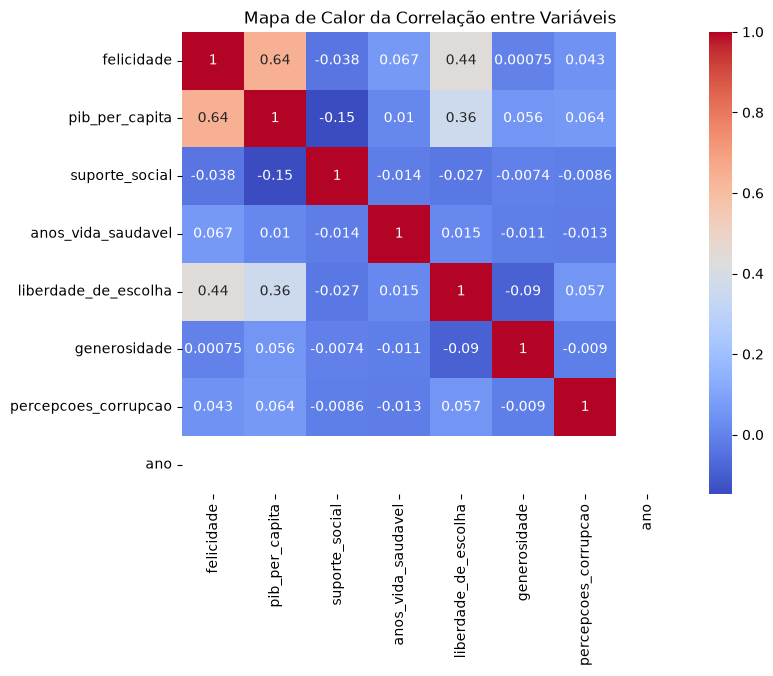

In [11]:
df_sem_texto = df_limpo.select_dtypes(exclude=['object'])
matriz_correlacao = df_sem_texto.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor da Correlação entre Variáveis')
plt.show()


# Identificando e removendo *outliers*

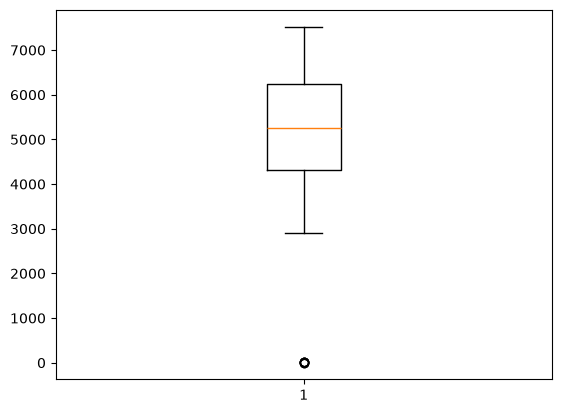

In [12]:
plt.boxplot(df_sem_texto['felicidade'])
plt.show()

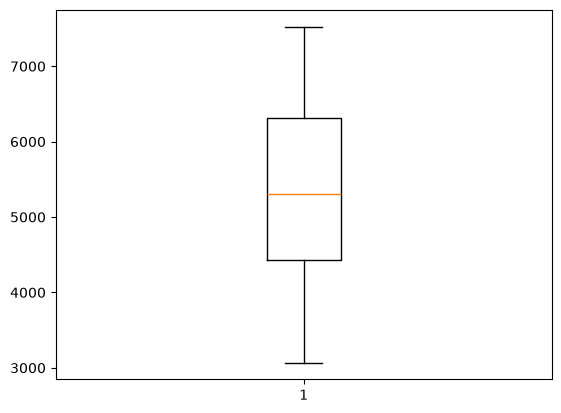

In [13]:
df_sem_texto = df_sem_texto[df_sem_texto['felicidade']>3000]
plt.boxplot(df_sem_texto['felicidade'])
plt.show()

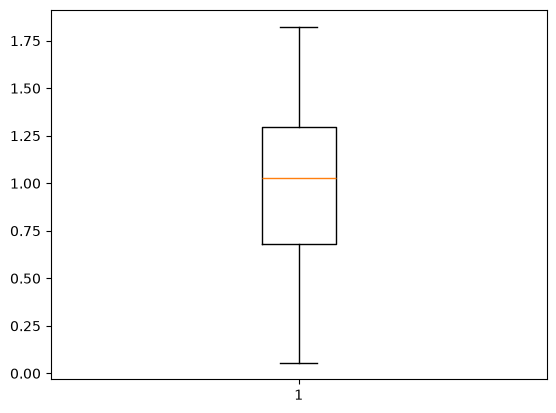

In [14]:
plt.boxplot(df_sem_texto['pib_per_capita'])
plt.show()

# Gráficos de dispersão

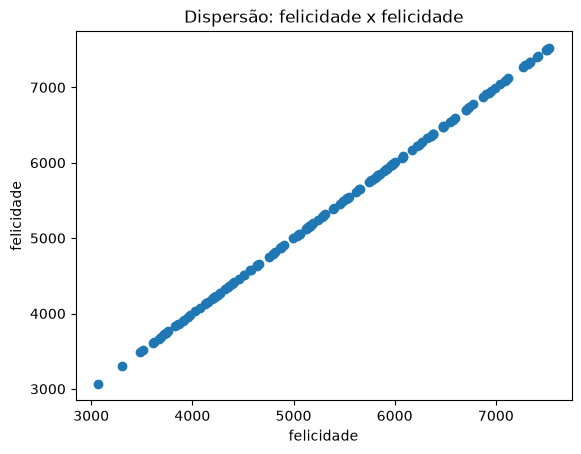

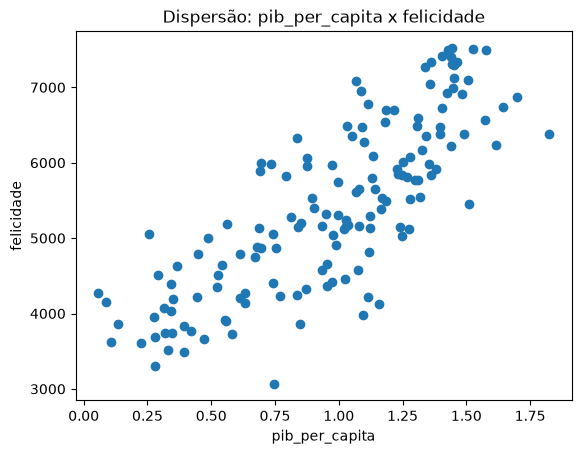

In [15]:
colunas_correlacionadas = ['felicidade', 'pib_per_capita']


for col in colunas_correlacionadas:
    plt.figure()
    plt.scatter(df_sem_texto[col], df_sem_texto['felicidade'])
    plt.xlabel(col)
    plt.ylabel('felicidade')
    plt.title(f'Dispersão: {col} x felicidade')
    plt.show()

# Separação dos dados em treino e teste

In [16]:
X = df_sem_texto[['pib_per_capita']]
y = df_sem_texto['felicidade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# Modelo de regressão polinomial

--- Métricas da Regressão Polinomial (Grau 4) ---
R² (teste): 0.5548683200174132
MAE (Erro Absoluto Médio): 548.8906324038728
RMSE (Raiz do Erro Quadrático Médio): 666.2554861319217


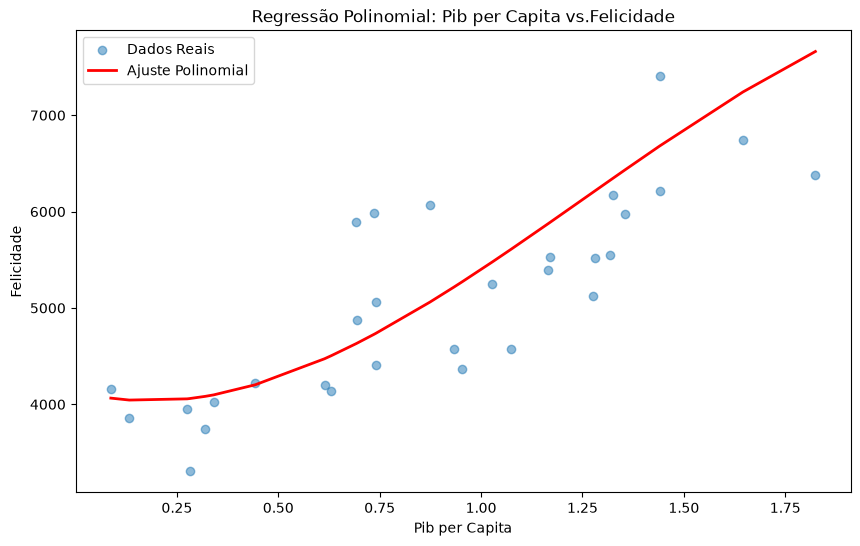

In [17]:
# 1. Preparação dos dados
X_poli_train = X_train[['pib_per_capita']]
X_poli_test = X_test[['pib_per_capita']]

# 2. Transformação Polinomial
poli_features = PolynomialFeatures(degree=3, include_bias=False)
X_poli_train_transformado = poli_features.fit_transform(X_poli_train)
X_poli_test_transformado = poli_features.transform(X_poli_test)

# 3. Treinamento do Modelo
poli_reg_model = LinearRegression()
poli_reg_model.fit(X_poli_train_transformado, y_train)

# 4. Avaliação do Modelo
y_poli_pred = poli_reg_model.predict(X_poli_test_transformado)
r2_poli = r2_score(y_test, y_poli_pred)
mae_poli = mean_absolute_error(y_test, y_poli_pred)
mse_poli = mean_squared_error(y_test, y_poli_pred)
rmse_poli = np.sqrt(mse_poli)

print("--- Métricas da Regressão Polinomial (Grau 4) ---")
print(f"R² (teste): {r2_poli}")
print(f"MAE (Erro Absoluto Médio): {mae_poli}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_poli}")

# Visualização do ajuste
plt.figure(figsize=(10, 6))
plt.scatter(X_poli_test, y_test, alpha=0.5, label='Dados Reais')
# Ordenar os valores para uma linha contínua
sort_axis = np.argsort(X_poli_test.iloc[:,0])
plt.plot(X_poli_test.iloc[sort_axis], y_poli_pred[sort_axis], color='red', linewidth=2, label='Ajuste Polinomial')
plt.title('Regressão Polinomial: Pib per Capita vs.Felicidade')
plt.xlabel('Pib per Capita')
plt.ylabel('Felicidade')
plt.legend()
plt.show()

# Análise de resíduos

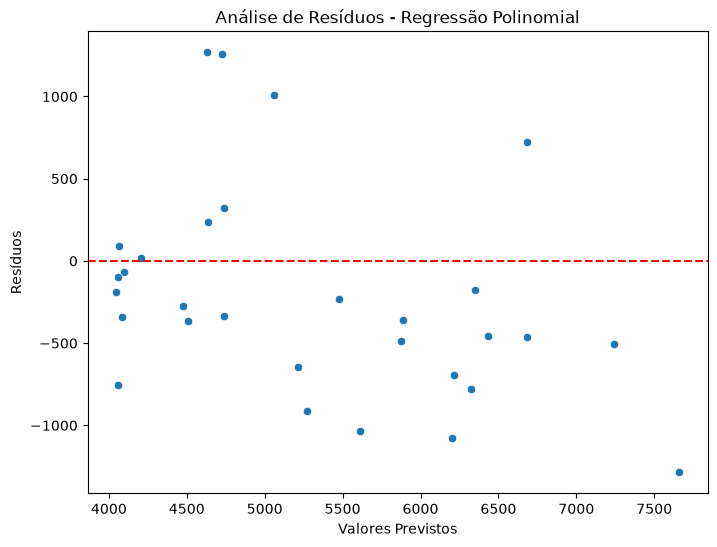

Um bom gráfico de resíduos desse tipo deve ser aleatório, ou seja, não deve ter um padrão


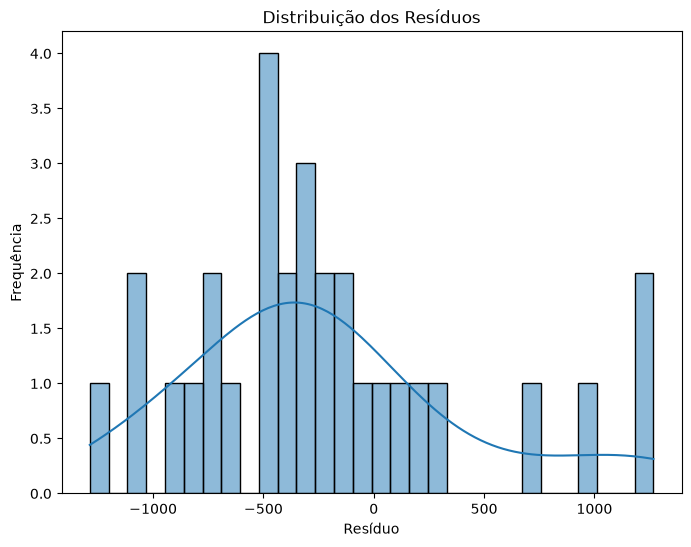

Quanto mais próximo de uma curva de sino, ou distribuição normal, melhor


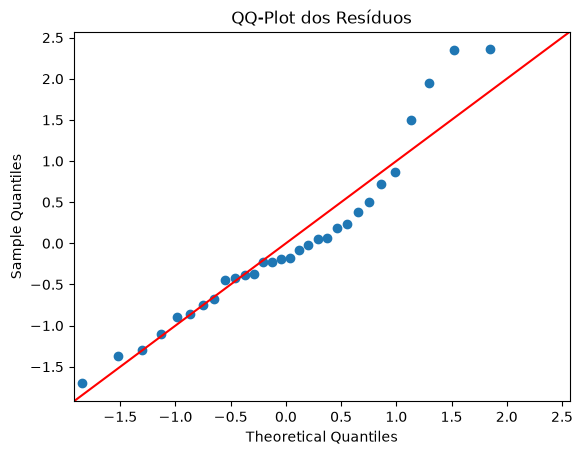

Verificar se está seguindo aproximadamente a linha


In [18]:
# Cálculo dos resíduos
residuos_poli = y_test - y_poli_pred

# 1. Gráfico de Dispersão: Previstos vs. Resíduos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_poli_pred, y=residuos_poli)
plt.axhline(0, color='red', linestyle='--')
plt.title('Análise de Resíduos - Regressão Polinomial')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.show()
print("Um bom gráfico de resíduos desse tipo deve ser aleatório, ou seja, não deve ter um padrão")

# 2. Histograma dos Resíduos
plt.figure(figsize=(8, 6))
sns.histplot(residuos_poli, kde=True, bins=30)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduo')
plt.ylabel('Frequência')
plt.show()
print("Quanto mais próximo de uma curva de sino, ou distribuição normal, melhor")

# 3. QQ-Plot para verificar a normalidade dos resíduos
sm.qqplot(residuos_poli, line='45', fit=True)
plt.title('QQ-Plot dos Resíduos')
plt.show()
print("Verificar se está seguindo aproximadamente a linha")

# Regressão linear comprado a regressão polinomial

--- Métricas da Regressão Linear Simples ---
R² (teste): 0.57339209554616
MAE (Erro Absoluto Médio): 549.4760680412112
RMSE (Raiz do Erro Quadrático Médio): 652.2453553133168


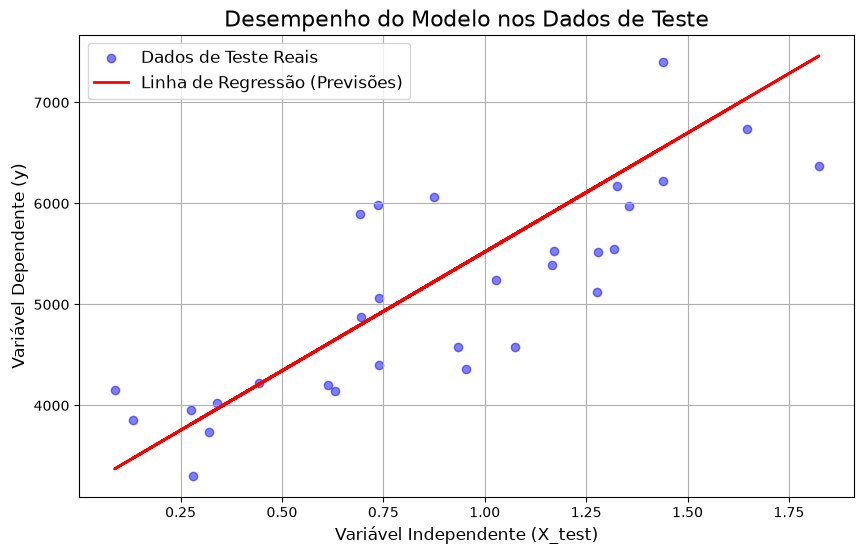

In [19]:
#Treinamento
regressao_linear = LinearRegression()
regressao_linear.fit(X_train, y_train)

#Predição
preditos_linreg = regressao_linear.predict(X_test)
r2_linreg = r2_score(y_test, preditos_linreg)
mae_linreg= mean_absolute_error(y_test, preditos_linreg)
mse_linreg= mean_squared_error(y_test, preditos_linreg)
rmse_linreg= np.sqrt(mse_linreg)

print("--- Métricas da Regressão Linear Simples ---")
print(f"R² (teste): {r2_linreg}")
print(f"MAE (Erro Absoluto Médio): {mae_linreg}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_linreg}")


#Gráfico de dispersão com a linha
plt.figure(figsize=(10, 6))

# 1. Gráfico de Dispersão usando os DADOS DE TESTE (a forma correta de avaliar)
plt.scatter(X_test, y_test, color='blue', label='Dados de Teste Reais', alpha=0.5)

# 2. Gráfico de Linha com as PREVISÕES feitas sobre os DADOS DE TESTE
plt.plot(X_test, preditos_linreg, color='red', linewidth=2, label='Linha de Regressão (Previsões)')

# Adiciona títulos e legendas para maior clareza
plt.title('Desempenho do Modelo nos Dados de Teste', fontsize=16)
plt.xlabel('Variável Independente (X_test)', fontsize=12)
plt.ylabel('Variável Dependente (y)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True) # Adiciona uma grade para melhor visualização

# Mostra o gráfico
plt.show()